# Session 1 — Python Refresher & NumPy Practical
## From Python Basics to the Foundation of Scientific Computing

This notebook is divided into two parts that mirror the slides exactly:

**Part A — Python Refresher**
1. Variables & Data Types
2. Control Flow — if/elif/else, for, while
3. Functions
4. Data Structures — lists, dicts, sets, tuples
5. List Comprehensions
6. Importing Libraries

**Part B — NumPy**

7. Why NumPy? (speed comparison)
8. Creating Arrays
9. Array Properties & Indexing
10. Math Operations & Broadcasting
11. Aggregation & Statistical Functions
12. Reshaping & Manipulation
13. Mini Project — simulating a grayscale image

> **How to use this notebook:** Read the explanation in each markdown cell, then run the code cell below it. Try changing values and re-running to build intuition.

---
# Part A — Python Refresher

A quick hands-on review of the Python building blocks you will need throughout this course. Even if you have seen these before, run each cell and make sure everything makes sense before moving on.

## 1 — Variables & Data Types

Python has four core numeric/text types you will use constantly. Notice that you never need to declare the type — Python figures it out automatically.

In [1]:
# ── Basic types ─────────────────────────────────────────────────

age        = 25          # int   — whole numbers
height     = 1.75        # float — decimal numbers
name       = "Alice"     # str   — text (single or double quotes)
is_student = True        # bool  — True or False

print(age, type(age))
print(height, type(height))
print(name, type(name))
print(is_student, type(is_student))

25 <class 'int'>
1.75 <class 'float'>
Alice <class 'str'>
True <class 'bool'>


In [7]:
# ── Type conversion ─────────────────────────────────────────────
# You often need to convert between types, e.g. reading a number from a string.

x = "42"             # this is a string, not a number!
print(type(x), x + "8")          # string concatenation: "428"

x_int = int(x)       # convert to integer
print(type(x_int), x_int + 8)    # now it's arithmetic: 50

print(float("3.14"))              # string → float
print(str(100))                   # int → string
print(bool(0), bool(1), bool("")) # 0 and "" are "falsy"

<class 'str'> 428
<class 'int'> 50
3.14
100
False True False


In [10]:
float("Dhruv")  # This will raise a ValueError, as "Dhruv" cannot be converted to a float

ValueError: could not convert string to float: 'Dhruv'

In [15]:
# ── String formatting (f-strings) ───────────────────────────────
# f-strings are the modern, clean way to embed variables inside strings.

model   = "ResNet-50"
accuracy = 94.7888

print(f"Model: {model}")
print(f"Accuracy: {accuracy:.1f}%")            # 1 decimal place
print(f"Accuracy as int: {int(accuracy)}")
print(f"{'Model':<12} {'Accuracy':>10}")        # alignment
print(f"{model:<12} {accuracy:>10.2f}")

Model: ResNet-50
Accuracy: 94.8%
Accuracy as int: 94
Model          Accuracy
ResNet-50         94.79


---
## 2 — Control Flow

Control flow lets your program make decisions and repeat actions. The two pillars are **conditionals** (`if`/`elif`/`else`) and **loops** (`for`, `while`).

> **Important:** Python uses **indentation** (4 spaces) to define code blocks — there are no curly braces `{}` like in other languages.

In [18]:
# ── if / elif / else ────────────────────────────────────────────

score = 72

if score >= 90:
    grade = "A"
elif score >= 75:
    grade = "B"
elif score >= 60:
    grade = "C"
else:
    grade = "F"

print(f"Score: {score} → Grade: {grade}")

# One-liner conditional (ternary expression)
result = "Pass" if score >= 60 else "Fail"
print(f"Result: {result}")

Score: 72 → Grade: C
Result: Pass


In [19]:
# ── for loops ───────────────────────────────────────────────────

# Iterate over a list
fruits = ["apple", "banana", "cherry"]
for fruit in fruits:
    print(f"  {fruit}")

print()

# range() generates a sequence of numbers
for i in range(5):          # 0, 1, 2, 3, 4
    print(i, end=" ")
print()

for i in range(1, 10, 2):   # start=1, stop=10, step=2
    print(i, end=" ")
print()

# enumerate() gives both index and value — very useful!
for idx, fruit in enumerate(fruits):
    print(f"  [{idx}] {fruit}")

  apple
  banana
  cherry

0 1 2 3 4 
1 3 5 7 9 
  [0] apple
  [1] banana
  [2] cherry


In [ ]:
# ── while loops ─────────────────────────────────────────────────
# Use while when you don't know the number of iterations in advance.

epoch = 1
loss  = 1.0

while loss > 0.1:               # keep training until loss is small enough
    loss = loss * 0.6           # simulated loss reduction each epoch
    print(f"  Epoch {epoch}: loss = {loss:.4f}")
    epoch += 1

print(f"Training done after {epoch-1} epochs!")

# break and continue
print("\nbreak example:")
for i in range(10):
    if i == 5:
        break                   # exit loop immediately
    print(i, end=" ")

print("\n\ncontinue example:")
for i in range(10):
    if i % 2 == 0:
        continue                # skip even numbers, jump to next iteration
    print(i, end=" ")

  Epoch 1: loss = 0.6000
  Epoch 2: loss = 0.3600
  Epoch 3: loss = 0.2160
  Epoch 4: loss = 0.1296
  Epoch 5: loss = 0.0778
Training done after 5 epochs!

break example:
0 1 2 3 4 

continue example:
1 3 5 7 9 

---
## 3 — Functions

Functions let you **name and reuse a block of code**. In ML/CV you will write functions constantly — for loading data, preprocessing images, training a model, evaluating results, and more.

Key ideas:
- `def` defines a function
- `return` sends a value back to the caller
- Parameters can have **default values**
- Functions should do **one thing** and do it clearly

In [ ]:
# ── Defining and calling functions ──────────────────────────────

def greet(name):
    """Return a greeting string."""     # docstring — describes the function
    return f"Hello, {name}!"

message = greet("Dhruv")
print(message)

# ── Default parameter values ─────────────────────────────────────
def power(base, exponent=2):           # exponent defaults to 2 (square)
    return base ** exponent

print(power(3))         # uses default: 3² = 9
print(power(3, 3))      # override: 3³ = 27
print(power(2, 10))     # 2¹⁰ = 1024

Hello, Dhruv!
9
27
1024


In [28]:
# ── Returning multiple values ────────────────────────────────────
# Python functions can return more than one value as a tuple.

def min_max(numbers):
    """Return the minimum and maximum of a list."""
    return min(numbers), max(numbers)

low, high = min_max([5, 2, 8, 1, 9, 3])
print(f"Min: {low}, Max: {high}")

# ── A practical CV-style function ───────────────────────────────
def normalise(value, old_min=0, old_max=255, new_min=0.0, new_max=1.0):
    """Map a value from one range to another."""
    return (value - old_min) / (old_max - old_min) * (new_max - new_min) + new_min

print(normalise(0))     # 0.0 (black pixel)
print(normalise(128))   # 0.502 (mid-grey)
print(normalise(255))   # 1.0 (white pixel)

Min: 1, Max: 9
0.0
0.5019607843137255
1.0


In [29]:
# ── Lambda functions ─────────────────────────────────────────────
# A lambda is a small, anonymous function written in one line.
# Useful for short operations — especially sorting and filtering.

square   = lambda x: x ** 2
add      = lambda x, y: x + y

print(square(5))        # 25
print(add(3, 7))        # 10

# Practical: sort a list of tuples by the second element
models = [("ResNet", 94.2), ("VGG", 91.5), ("MobileNet", 89.0), ("EfficientNet", 96.1)]
sorted_models = sorted(models, key=lambda m: m[1], reverse=True)
for name, acc in sorted_models:
    print(f"  {name:<14} {acc:.1f}%")

25
10
  EfficientNet   96.1%
  ResNet         94.2%
  VGG            91.5%
  MobileNet      89.0%


---
## 4 — Data Structures

Python has four built-in collection types. Choosing the right one for the job makes your code cleaner and faster.

| Type | Syntax | Ordered | Mutable | Duplicates |
|------|--------|---------|---------|------------|
| List | `[1, 2, 3]` | Yes | Yes | Yes |
| Dictionary | `{"a": 1}` | Yes (3.7+) | Yes | Keys: No |
| Set | `{1, 2, 3}` | No | Yes | No |
| Tuple | `(1, 2, 3)` | Yes | **No** | Yes |

In [31]:
# ── Lists ────────────────────────────────────────────────────────
# Ordered, mutable collection. Your go-to for sequences.

classes = ["cat", "dog", "bird"]

# Access by index (0-based, negative counts from end)
print(classes[0])       # "cat"
print(classes[-1])      # "bird"

# Modify
classes.append("fish")          # add to end
print(classes)
classes.insert(1, "hamster")    # insert at index
print(classes)
classes.remove("dog")           # remove by value
popped = classes.pop()          # remove and return last element

print(classes)
print("Popped:", popped)
print("Length:", len(classes))

# Slice: list[start:stop:step]
numbers = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
print(numbers[2:6])     # [2, 3, 4, 5]
print(numbers[::2])     # [0, 2, 4, 6, 8]  (every 2nd)
print(numbers[::-1])    # reversed

cat
bird
['cat', 'dog', 'bird', 'fish']
['cat', 'hamster', 'dog', 'bird', 'fish']
['cat', 'hamster', 'bird']
Popped: fish
Length: 3
[2, 3, 4, 5]
[0, 2, 4, 6, 8]
[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]


In [34]:
# ── Dictionaries ─────────────────────────────────────────────────
# Key–value pairs. Perfect for storing labelled data (class names,
# config settings, model results, etc.)

model_results = {
    "model":    "ResNet-50",
    "accuracy": 94.7,
    "params":   25_000_000,
    "pretrained": True
}

# Access by key
print(model_results["model"])
print(model_results["accuracy"])

# Safe access with .get() — returns None (or a default) if key missing
print(model_results.get("loss", "N/A"))

# Add / update
model_results["loss"] = 0.18
model_results["accuracy"] = 95.1   # update existing key

# Iterate
for key, value in model_results.items():
    print(f"  {key}: {value}")

ResNet-50
94.7
N/A
  model: ResNet-50
  accuracy: 95.1
  params: 25000000
  pretrained: True
  loss: 0.18


In [35]:
# ── Sets ─────────────────────────────────────────────────────────
# Unordered collection of UNIQUE values. Great for deduplication.

detected    = {"cat", "dog", "cat", "bird", "dog"}   # duplicates removed
ground_truth = {"cat", "dog", "fish"}

print("Detected (unique):", detected)

# Set operations — very useful in evaluation metrics
print("Intersection (both):", detected & ground_truth)   # TP-like
print("Union (either):     ", detected | ground_truth)
print("Only in detected:   ", detected - ground_truth)   # FP-like
print("Only in truth:      ", ground_truth - detected)   # FN-like

Detected (unique): {'cat', 'bird', 'dog'}
Intersection (both): {'cat', 'dog'}
Union (either):      {'fish', 'dog', 'cat', 'bird'}
Only in detected:    {'bird'}
Only in truth:       {'fish'}


In [37]:
# ── Tuples ───────────────────────────────────────────────────────
# Like a list but IMMUTABLE — it can never be changed after creation.
# Use tuples for things that should stay fixed: image shape, RGB colour, coordinates.

image_shape = (480, 640, 3)     # (height, width, channels)
point       = (100, 250)        # (x, y) pixel coordinate
color_red   = (255, 0, 0)       # RGB

print("Image shape:", image_shape)
print("Height:", image_shape[0], "| Width:", image_shape[1])

# Tuple unpacking — very common Python idiom
h, w, c = image_shape
print(f"H={h}, W={w}, C={c}")

# Trying to modify a tuple raises an error — uncomment to see:
image_shape[0] = 720    # TypeError: 'tuple' object does not support item assignment

Image shape: (480, 640, 3)
Height: 480 | Width: 640
H=480, W=640, C=3


TypeError: 'tuple' object does not support item assignment

---
## 5 — List Comprehensions

List comprehensions are a concise, Pythonic way to create lists from sequences. They replace a `for` loop + `append` in a single readable line.

```python
# Traditional loop
result = []
for x in iterable:
    result.append(expression)

# List comprehension — same result, one line
result = [expression for x in iterable]
```

In [38]:
# ── Basic list comprehension ─────────────────────────────────────

# Squares of 0–9
squares = [x**2 for x in range(10)]
print("Squares:", squares)

# Normalise a list of pixel values to [0, 1]
pixels     = [0, 64, 128, 192, 255]
normalised = [p / 255.0 for p in pixels]
print("Normalised:", [round(n, 3) for n in normalised])

Squares: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
Normalised: [0.0, 0.251, 0.502, 0.753, 1.0]


In [39]:
# ── Filtering with a condition ───────────────────────────────────
# Add "if condition" at the end to keep only matching items.

numbers = list(range(20))

evens   = [x for x in numbers if x % 2 == 0]
print("Evens:", evens)

# Keep only bright pixel values (>= 128)
pixel_data = [34, 210, 89, 255, 12, 180, 67, 145]
bright     = [p for p in pixel_data if p >= 128]
print("Bright pixels:", bright)

Evens: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Bright pixels: [210, 255, 180, 145]


In [40]:
# ── Dictionary & set comprehensions ─────────────────────────────

# Dict comprehension: {key: value for ...}
class_names = ["cat", "dog", "bird", "fish"]
label_map   = {name: idx for idx, name in enumerate(class_names)}
print("Label map:", label_map)

# Reverse lookup: idx → name
reverse_map = {idx: name for name, idx in label_map.items()}
print("Reverse map:", reverse_map)

# Set comprehension: {expression for ...}  — unique values only
raw_labels   = [0, 2, 1, 0, 3, 2, 1, 0]
unique_labels = {label for label in raw_labels}
print("Unique labels:", unique_labels)

Label map: {'cat': 0, 'dog': 1, 'bird': 2, 'fish': 3}
Reverse map: {0: 'cat', 1: 'dog', 2: 'bird', 3: 'fish'}
Unique labels: {0, 1, 2, 3}


---
## 6 — Importing Libraries

Python's real power comes from its ecosystem of libraries. Instead of writing everything from scratch, you import code written by experts.

There are three import styles you will see everywhere in AI/CV projects:

In [41]:
# ── Three import styles ──────────────────────────────────────────

# Style 1: import the whole library, use with prefix
import math
print(math.sqrt(16))        # 4.0
print(math.pi)              # 3.14159...

# Style 2: import with a short alias (standard convention)
import numpy as np          # np is the UNIVERSAL alias — always use this
import random as rng

arr = np.array([1, 2, 3])
print(arr * 2)

# Style 3: import specific items directly (no prefix needed)
from math import sqrt, pi, floor
print(sqrt(25))             # no "math." needed
print(floor(3.9))           # 3

4.0
3.141592653589793
[2 4 6]
5.0
3


In [42]:
# ── The core AI/CV library aliases — memorise these ─────────────
# These are the standard, community-wide conventions.
# You will see them in every tutorial, paper, and codebase.

import numpy as np             # arrays & math
# import cv2                   # OpenCV — computer vision (install: pip install opencv-python)
# import matplotlib.pyplot as plt  # plotting
# import torch                 # PyTorch — deep learning
# import torch.nn as nn        # neural network layers
# from torchvision import transforms  # image transforms

# Demonstrate numpy is ready
print("NumPy:", np.__version__)
print("Pi from numpy:", np.pi)
print("Euler's number e:", np.e)

NumPy: 2.4.4
Pi from numpy: 3.141592653589793
Euler's number e: 2.718281828459045


---
# Part B — NumPy

Now that you are comfortable with Python basics, we move to **NumPy** — the library that makes Python fast enough for real-world AI and Computer Vision.

Every framework you will use (OpenCV, PyTorch, scikit-learn, Matplotlib) stores data as NumPy arrays under the hood. Mastering NumPy is non-negotiable.

In [1]:
import numpy as np
print("NumPy version:", np.__version__)
print("Ready to go!")

NumPy version: 2.2.6
Ready to go!


---
## Part 1 — Why NumPy?

Python lists are great for general programming, but they are **slow** for numerical work because Python processes each element one at a time.

NumPy stores data in a **contiguous block of memory** (like C arrays) and uses **vectorised operations** — the loop runs in optimised C instead of Python. The result is the same, but orders of magnitude faster.

Let's measure this directly.

In [ ]:
import time

N = 1_000_000  # one million elements

# --- Pure Python approach ---
python_list = list(range(N))

start = time.time()
result_py = [x * 2 for x in python_list]
py_time = time.time() - start

# --- NumPy approach ---
numpy_array = np.arange(N)

start = time.time()
result_np = numpy_array * 2
np_time = time.time() - start

print(f"Python list (loop):  {py_time * 1000:.2f} ms")
print(f"NumPy array (vectorised): {np_time * 1000:.2f} ms")
print(f"NumPy is ~{py_time / np_time:.0f}x faster")

---
## Part 2 — Creating Arrays

There are many ways to create NumPy arrays. The most common ones you will use every day are shown below.

In [ ]:
# ── From existing data ──────────────────────────────────────────

# 1D array from a Python list
a = np.array([10, 20, 30, 40, 50])
print("1D array:", a)

# 2D array (matrix) — a list of lists
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
print("\n2D matrix:\n", matrix)

# Specify the data type explicitly
floats = np.array([1, 2, 3], dtype=float)
print("\nFloat array:", floats, "| dtype:", floats.dtype)

In [ ]:
# ── Built-in generator functions ────────────────────────────────

print("np.zeros(4):        ", np.zeros(4))
print("np.ones((2, 3)):\n",   np.ones((2, 3)))
print("np.eye(3) — identity:\n", np.eye(3))
print("np.full((2,4), 7):\n",  np.full((2, 4), 7))

In [ ]:
# ── Range & evenly-spaced arrays ────────────────────────────────

# arange: like Python's range() but returns a NumPy array
print("np.arange(0, 10, 2):", np.arange(0, 10, 2))   # step = 2
print("np.arange(0, 1, 0.25):", np.arange(0, 1, 0.25))

# linspace: N evenly spaced values between start and stop (inclusive)
print("\nnp.linspace(0, 1, 5):", np.linspace(0, 1, 5))
print("np.linspace(0, 100, 6):", np.linspace(0, 100, 6))

In [ ]:
# ── Random arrays ───────────────────────────────────────────────

np.random.seed(42)  # fix seed so results are reproducible

# Random floats between 0 and 1
print("rand(3, 3):\n", np.random.rand(3, 3))

# Random integers — very useful for simulating pixel values!
pixels = np.random.randint(0, 256, size=(4, 4))
print("\nFake 4x4 grayscale image (pixel values 0–255):\n", pixels)

---
## Part 3 — Array Properties & Indexing

Before you can work with an array, you need to know its shape, size, and type. NumPy gives you these as simple attributes.

Then we look at indexing — how to pull out specific elements, rows, columns, or subregions. This is especially important for images, where you often need to crop a region or extract a colour channel.

In [ ]:
# ── Array properties ────────────────────────────────────────────

img = np.array([[100, 150, 200, 50],
                [ 30,  80, 120, 90],
                [200, 175, 255,  0]])

print("Array:\n", img)
print()
print("shape :", img.shape)   # (rows, cols)
print("ndim  :", img.ndim)    # number of dimensions
print("size  :", img.size)    # total elements
print("dtype :", img.dtype)   # data type

In [ ]:
# ── Indexing: single elements ────────────────────────────────────
# Syntax: array[row, col]  (0-indexed, just like Python lists)

print("img[0, 0] =", img[0, 0])   # top-left
print("img[1, 2] =", img[1, 2])   # row 1, col 2
print("img[-1, -1] =", img[-1, -1])  # bottom-right (negative indexing)

In [ ]:
# ── Slicing: rows, columns, sub-regions ─────────────────────────
# Syntax: array[row_start:row_end, col_start:col_end]
# ":" means "all"

print("All of row 0:        ", img[0, :])
print("All of col 1:        ", img[:, 1])
print("First 2 rows:      \n", img[0:2, :])
print("Top-left 2x2 crop: \n", img[0:2, 0:2])

In [ ]:
# ── Boolean masking — very powerful! ────────────────────────────
# Create a True/False mask based on a condition, then use it to
# select or modify elements.

print("Original:\n", img)

# Which pixels are "bright" (value > 150)?
bright_mask = img > 150
print("\nBright mask (True where > 150):\n", bright_mask)

# Get the actual bright pixel values
print("\nBright pixel values:", img[bright_mask])

# Replace all dark pixels (< 50) with 0 — common in image processing
img_copy = img.copy()
img_copy[img_copy < 50] = 0
print("\nAfter zeroing dark pixels:\n", img_copy)

---
## Part 4 — Math Operations & Broadcasting

NumPy performs operations **element-wise** by default — no loops required. When array shapes are compatible, NumPy can also **broadcast** (stretch) a smaller array to match a larger one automatically.

In [ ]:
# ── Element-wise arithmetic ──────────────────────────────────────

a = np.array([10, 20, 30, 40])
b = np.array([ 1,  2,  3,  4])

print("a       :", a)
print("b       :", b)
print("a + b   :", a + b)
print("a - b   :", a - b)
print("a * b   :", a * b)
print("a / b   :", a / b)
print("a ** 2  :", a ** 2)   # square every element
print("a % 3   :", a % 3)    # modulo

In [ ]:
# ── Math functions ───────────────────────────────────────────────

data = np.array([1.0, 4.0, 9.0, 16.0, 25.0])

print("data         :", data)
print("np.sqrt      :", np.sqrt(data))    # square root
print("np.log       :", np.round(np.log(data), 3))     # natural log
print("np.exp([1,2]):", np.round(np.exp([1, 2]), 4))   # e^x

In [ ]:
# ── Broadcasting: scalar on array ───────────────────────────────
# A single number is automatically "broadcast" to every element.
# This is extremely common in image processing.

image = np.array([[100, 150, 200],
                  [ 50,  80, 120]])

# Normalise pixel values from 0–255 range to 0.0–1.0 range
normalised = image / 255.0
print("Original pixel values:\n", image)
print("\nNormalised (divided by 255):\n", np.round(normalised, 3))

# Add brightness (+50) — "broadcast" the scalar 50 to every pixel
brighter = np.clip(image + 50, 0, 255)  # clip keeps values in [0, 255]
print("\nBrighter image (+50, clipped):\n", brighter)

In [ ]:
# ── Matrix multiplication ────────────────────────────────────────
# Use @ operator (or np.dot) for true matrix multiplication.
# This is the backbone of neural networks and linear algebra.

A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

print("A:\n", A)
print("\nB:\n", B)
print("\nA * B  (element-wise):\n", A * B)    # NOT matrix multiply
print("\nA @ B  (matrix multiply):\n", A @ B)  # TRUE matrix multiply
print("\nnp.dot(A, B):\n", np.dot(A, B))        # same result

---
## Part 5 — Aggregation & Statistical Functions

These functions **summarise** an entire array (or a row/column) into a single number. They are used constantly in data science and machine learning — for example, computing the mean loss during training, finding the class with the highest score, or normalising a dataset.

In [ ]:
# ── Global aggregations (across all elements) ────────────────────

scores = np.array([[85, 92, 78],
                   [90, 55, 88],
                   [70, 95, 60]])

print("Scores:\n", scores)
print()
print("Sum     :", np.sum(scores))
print("Mean    :", np.mean(scores))
print("Std Dev :", np.round(np.std(scores), 2))
print("Min     :", np.min(scores))
print("Max     :", np.max(scores))
print("Median  :", np.median(scores))

# argmin / argmax return the INDEX (flat) of the min/max value
print("\nIndex of min value (flat):", np.argmin(scores))
print("Index of max value (flat):", np.argmax(scores))

In [ ]:
# ── Axis-based operations ────────────────────────────────────────
# axis=0 → operate DOWN each column (result has shape = (num_cols,))
# axis=1 → operate ACROSS each row  (result has shape = (num_rows,))

print("Scores:\n", scores)
print()
print("Column means (axis=0):", np.mean(scores, axis=0))
print("Row means    (axis=1):", np.mean(scores, axis=1))
print()
print("Column sums  (axis=0):", np.sum(scores, axis=0))
print("Row sums     (axis=1):", np.sum(scores, axis=1))
print()
print("Best score per student (row max, axis=1):", np.max(scores, axis=1))

---
## Part 6 — Reshaping & Array Manipulation

In Computer Vision and ML you constantly need to **change the shape** of arrays — flattening an image into a vector before feeding it to a model, stacking multiple images into a batch, or transposing a matrix. NumPy makes this effortless.

In [2]:
# ── reshape ──────────────────────────────────────────────────────
# reshape does NOT copy data — it's just a new "view" of the same memory

flat = np.arange(12)   # [0, 1, 2, ..., 11]
print("Original (1D):", flat)

matrix_3x4 = flat.reshape(3, 4)
print("\nReshaped to (3, 4):\n", matrix_3x4)

matrix_2x6 = flat.reshape(2, 6)
print("\nReshaped to (2, 6):\n", matrix_2x6)

# Pass -1 to let NumPy figure out one dimension automatically
auto = flat.reshape(4, -1)   # 4 rows, auto-calculate columns
print("\nReshaped to (4, -1) → shape:", auto.shape, "\n", auto)

Original (1D): [ 0  1  2  3  4  5  6  7  8  9 10 11]

Reshaped to (3, 4):
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Reshaped to (2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]

Reshaped to (4, -1) → shape: (4, 3) 
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


In [3]:
matrix_3x5 = flat.reshape(3, 5)

ValueError: cannot reshape array of size 12 into shape (3,5)

In [4]:
# ── flatten & ravel ──────────────────────────────────────────────
# flatten() always returns a COPY; ravel() returns a view when possible

m = np.array([[1, 2, 3],
              [4, 5, 6]])

print("Matrix:\n", m)
print("\nflatten():", m.flatten())   # always a copy
print("ravel()  :", m.ravel())       # usually a view (more efficient)

Matrix:
 [[1 2 3]
 [4 5 6]]

flatten(): [1 2 3 4 5 6]
ravel()  : [1 2 3 4 5 6]


In [5]:
# ── Transpose ────────────────────────────────────────────────────
# .T swaps rows and columns — (rows, cols) becomes (cols, rows)

A = np.array([[1, 2, 3],
              [4, 5, 6]])

print("A shape:", A.shape, "\n", A)
print("\nA.T shape:", A.T.shape, "\n", A.T)

A shape: (2, 3) 
 [[1 2 3]
 [4 5 6]]

A.T shape: (3, 2) 
 [[1 4]
 [2 5]
 [3 6]]


In [6]:
# ── Stacking arrays ──────────────────────────────────────────────
# Stack arrays together to combine data.
# In CV: stacking images to create a batch, or colour channels to make RGB.

row1 = np.array([1, 2, 3])
row2 = np.array([4, 5, 6])
row3 = np.array([7, 8, 9])

# vstack: stack vertically (add new rows)
vertical = np.vstack([row1, row2, row3])
print("vstack:\n", vertical)

# hstack: stack horizontally (add new columns)
horizontal = np.hstack([row1, row2, row3])
print("\nhstack:", horizontal)

# concatenate: the general version (you specify the axis)
concat_rows = np.concatenate([row1.reshape(1,-1), row2.reshape(1,-1)], axis=0)
print("\nconcatenate (axis=0):\n", concat_rows)

vstack:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

hstack: [1 2 3 4 5 6 7 8 9]

concatenate (axis=0):
 [[1 2 3]
 [4 5 6]]


---
## Part 7 — Mini Project: Simulating a Grayscale Image

Let's bring everything together. We will:
1. Create a fake grayscale image using random pixel values
2. Inspect its properties
3. Crop a region of interest (ROI)
4. Analyse pixel statistics
5. Apply brightness and contrast adjustments
6. Threshold it to create a binary mask

This is exactly the kind of workflow you will use every day in Computer Vision!

In [7]:
# Step 1 — Create a fake 8x8 grayscale image
np.random.seed(0)
image = np.random.randint(0, 256, size=(8, 8), dtype=np.uint8)

print("=== Simulated Grayscale Image (8x8) ===")
print(image)
print()
print("Shape :", image.shape)
print("Dtype :", image.dtype)
print("Size  :", image.size, "pixels")

=== Simulated Grayscale Image (8x8) ===
[[172  10 127 140  47 170 196 151]
 [117 166  22 183 192 204  33 216]
 [ 67 179  78 154 251  82 162 219]
 [195 118 125 139 103 125 229 216]
 [  9 164 116 108 211 222 161 159]
 [ 21  81  89 165 242 214 102  98]
 [ 36 183   5 112  87  58  43  76]
 [ 70  60  75 228 216 189 132  14]]

Shape : (8, 8)
Dtype : uint8
Size  : 64 pixels


In [8]:
# Step 2 — Analyse pixel statistics
print("=== Pixel Statistics ===")
print(f"Min pixel value  : {np.min(image)}")
print(f"Max pixel value  : {np.max(image)}")
print(f"Mean brightness  : {np.mean(image):.2f}")
print(f"Std deviation    : {np.std(image):.2f}")
print(f"Median           : {np.median(image):.1f}")

# Count how many "bright" pixels there are (value >= 200)
bright_pixels = np.sum(image >= 200)
print(f"\nBright pixels (>= 200): {bright_pixels} out of {image.size}")

=== Pixel Statistics ===
Min pixel value  : 5
Max pixel value  : 251
Mean brightness  : 130.22
Std deviation    : 67.55
Median           : 129.5

Bright pixels (>= 200): 12 out of 64


In [9]:
# Step 3 — Crop a Region of Interest (ROI)
# In real CV, you do this to focus on a face, an object, a licence plate, etc.

roi = image[2:6, 2:6]   # rows 2–5, cols 2–5 → a 4x4 region
print("=== Cropped Region of Interest (rows 2:6, cols 2:6) ===")
print(roi)
print("ROI shape:", roi.shape)

=== Cropped Region of Interest (rows 2:6, cols 2:6) ===
[[ 78 154 251  82]
 [125 139 103 125]
 [116 108 211 222]
 [ 89 165 242 214]]
ROI shape: (4, 4)


In [10]:
# Step 4 — Normalise the image to [0.0, 1.0]
# Neural networks expect float input, not uint8 integers.

image_float = image.astype(np.float32)   # convert to float first
normalised   = image_float / 255.0

print("=== Normalised Image (first 3 rows) ===")
print(np.round(normalised[:3], 3))
print("\ndtype after normalisation:", normalised.dtype)
print(f"Value range: {normalised.min():.3f} → {normalised.max():.3f}")

=== Normalised Image (first 3 rows) ===
[[0.675 0.039 0.498 0.549 0.184 0.667 0.769 0.592]
 [0.459 0.651 0.086 0.718 0.753 0.8   0.129 0.847]
 [0.263 0.702 0.306 0.604 0.984 0.322 0.635 0.859]]

dtype after normalisation: float32
Value range: 0.020 → 0.984


In [11]:
# Step 5 — Apply a threshold to create a binary mask
# Any pixel brighter than the mean becomes white (255), rest becomes black (0).
# This is the basis of many segmentation techniques.

threshold = int(np.mean(image))
binary    = np.where(image >= threshold, 255, 0).astype(np.uint8)

print(f"=== Binary Mask (threshold = mean = {threshold}) ===")
print("Original:\n", image)
print("\nBinary mask (0 or 255):\n", binary)
print(f"\nWhite pixels: {np.sum(binary == 255)}  |  Black pixels: {np.sum(binary == 0)}")

=== Binary Mask (threshold = mean = 130) ===
Original:
 [[172  10 127 140  47 170 196 151]
 [117 166  22 183 192 204  33 216]
 [ 67 179  78 154 251  82 162 219]
 [195 118 125 139 103 125 229 216]
 [  9 164 116 108 211 222 161 159]
 [ 21  81  89 165 242 214 102  98]
 [ 36 183   5 112  87  58  43  76]
 [ 70  60  75 228 216 189 132  14]]

Binary mask (0 or 255):
 [[255   0   0 255   0 255 255 255]
 [  0 255   0 255 255 255   0 255]
 [  0 255   0 255 255   0 255 255]
 [255   0   0 255   0   0 255 255]
 [  0 255   0   0 255 255 255 255]
 [  0   0   0 255 255 255   0   0]
 [  0 255   0   0   0   0   0   0]
 [  0   0   0 255 255 255 255   0]]

White pixels: 32  |  Black pixels: 32


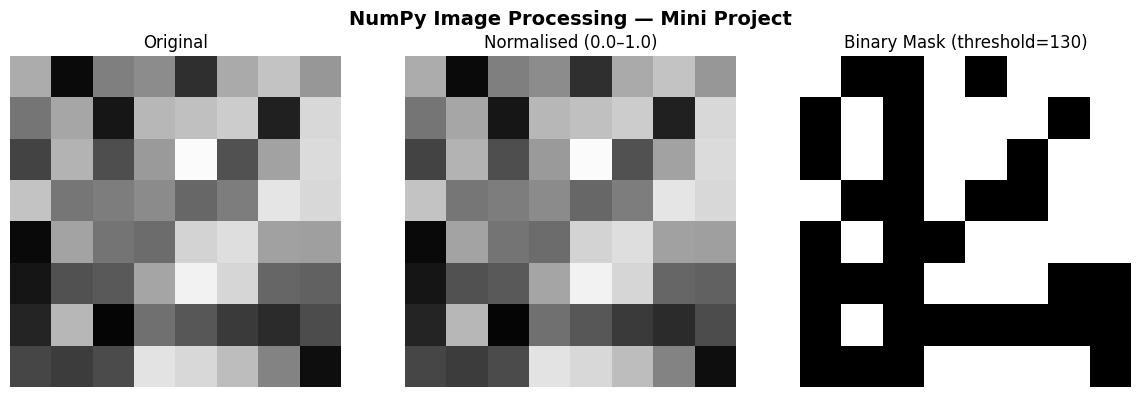

In [12]:
# Step 6 — Visualise with Matplotlib
# (Run this cell only if matplotlib is installed: pip install matplotlib)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image,      cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(normalised, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Normalised (0.0–1.0)")
axes[1].axis("off")

axes[2].imshow(binary,     cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"Binary Mask (threshold={threshold})")
axes[2].axis("off")

plt.suptitle("NumPy Image Processing — Mini Project", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Exercises — Practice on Your Own

Try the following challenges to solidify what you've learned.

### Exercise 1 — Gradients
Create a 1D array of 10 evenly spaced values from 0 to 255 using `np.linspace`, then reshape it into a 2x5 matrix.

### Exercise 2 — Matrix Stats
Create a random 5×5 matrix of integers between 0 and 100. Find:
- The mean of each row
- The maximum value in each column
- The index (row, col) of the overall maximum value using `np.unravel_index(np.argmax(arr), arr.shape)`

### Exercise 3 — Channel Simulation
Simulate a tiny **colour image** by creating three separate 4×4 arrays (R, G, B channels) with random values. Stack them along a new third axis using `np.stack([R, G, B], axis=2)` to get a `(4, 4, 3)` array — the same format as a real colour image.

### Exercise 4 — Contrast Stretching
Take a grayscale image array and apply contrast stretching to map its pixel range to [0, 255]:
```
stretched = ((image - image.min()) / (image.max() - image.min()) * 255).astype(np.uint8)
```
Verify the min is 0 and max is 255 after the operation.

In [ ]:
# Exercise 1 — your code here


In [ ]:
# Exercise 2 — your code here


In [ ]:
# Exercise 3 — your code here


In [ ]:
# Exercise 4 — your code here
